In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("/content/Student_Dataset_Messy.xlsx")

DATA CLEANING

In [62]:
text_cols=[col for col in df.columns if df[col].dtype=="object"]
for i  in text_cols:
  df[i]=df[i].astype(str).str.strip()
  df[i]=df[i].replace({"nan":np.nan,"":np.nan})



In [63]:
df['City']=df['City'].str.title()
df['Program']=df['Program'].str.title()


In [64]:
gender_map={"MALE":"male","M":"male","FEMALE":"female","F":"female"}
for i in df['Gender']:
  if pd.notna(i):
    i=i.upper()
    if i in gender_map:
      df['Gender'].replace(i,gender_map[i],inplace=True)



/tmp/ipykernel_12838/2521879137.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(i,gender_map[i],inplace=True)


In [65]:
df["Gender"]=df["Gender"].str.title()

In [66]:
df["Program"]=df['Program'].replace("Engg","Engineering")

In [67]:
numeric_cols = ["Attendance", "Pre Test", "Post Test"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [68]:
for col in numeric_cols:
  invalid=(df[col]<0)|(df[col]>100)
  df.loc[invalid, col] = np.nan


In [69]:
for col in numeric_cols:
  df[col]=df[col].fillna(df[col].median())# trying to apply the median of the column to na values so its doesnt affect much
text2_cols={"City","Gender","Program"}
for col2 in text2_cols:
 df[col2]=df[col2].fillna(df[col2].mode()[0]) # applying the most frequent cateogorical value

In [70]:
df=df.drop_duplicates()

In [71]:
def normalize(sid):
  stid=str(sid)
  dig=""
  for ch in stid:
    if(ch.isdigit()):
        dig=dig+ch
  if(dig!=""):
   stid=f"STU{dig}"
   return stid

  return sid



In [72]:
df['Student ID']=df['Student ID'].apply(normalize)

In [73]:
exsisting_id=set()
new_id=[]
maxy=[]
for s in df['Student ID']:
  maxy.append(int(s[3:]))
max_id=max(maxy)
for s in df['Student ID']:
  if s in exsisting_id:
    max_id=max_id+1
    new_id.append(f"STU{max_id:03d}")
    exsisting_id.add(f"STU{max_id:03d}")
  else:
    new_id.append(s)
  exsisting_id.add(s)
df['Student ID']=new_id

In [74]:
df = df.reset_index(drop=True)# reset the order

In [75]:
df.to_excel("/content/Student_Dataset_Messy.xlsx",index=False,sheet_name="final")

NOW WE COME TO THE PART OF ANALYSIS WE WILL ANSWER CERTAIN QUESTIONS

In [76]:
df["Improvement"]=df["Post Test"]-df["Pre Test"]

In [77]:
city=df.groupby("City")["Improvement"].median()

CITY VS IMPROVEMENT

Text(0, 0.5, 'Improvement')

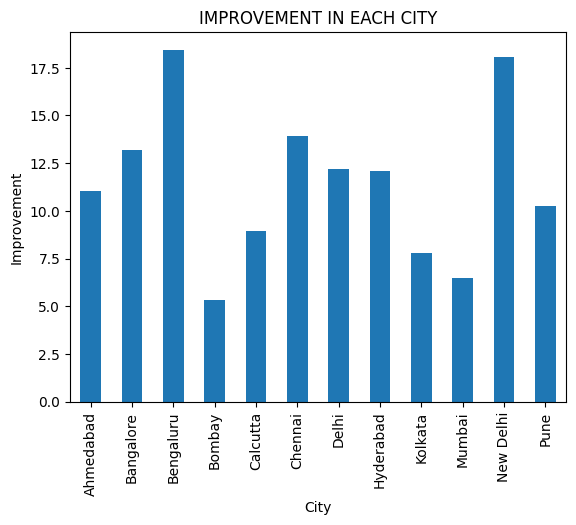

In [78]:
city.plot(kind="bar")
plt.title("IMPROVEMENT IN EACH CITY")
plt.xlabel("City")
plt.ylabel("Improvement")

PROGRAM Vs IMPROVEMENT

Text(0, 0.5, 'Improvement')

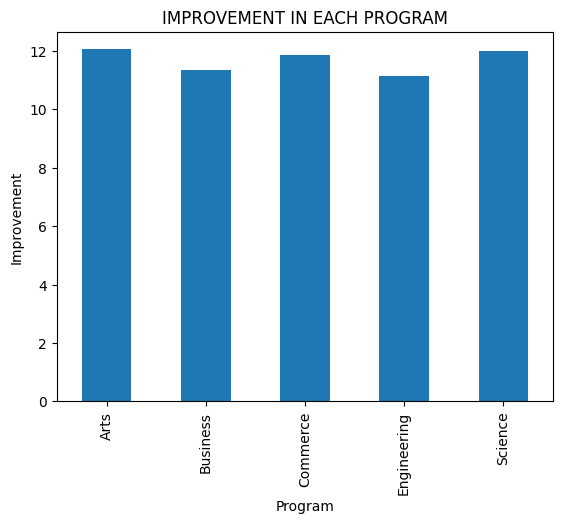

In [79]:
program=df.groupby("Program")["Improvement"].median()
program.plot(kind="bar")
plt.title("IMPROVEMENT IN EACH PROGRAM")
plt.xlabel("Program")
plt.ylabel("Improvement")

GENDER VS IMPROVEMENT

Text(0, 0.5, 'Improvement')

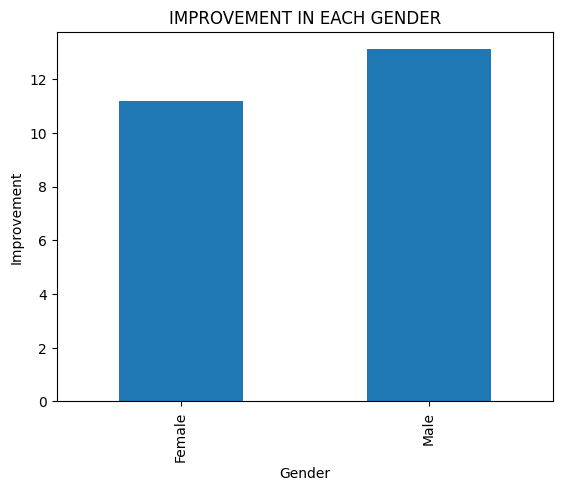

In [80]:
gender=df.groupby("Gender")["Improvement"].median()
gender.plot(kind="bar")
plt.title("IMPROVEMENT IN EACH GENDER")
plt.xlabel("Gender")
plt.ylabel("Improvement")

ATTENDANCE VS IMPROVEMENT

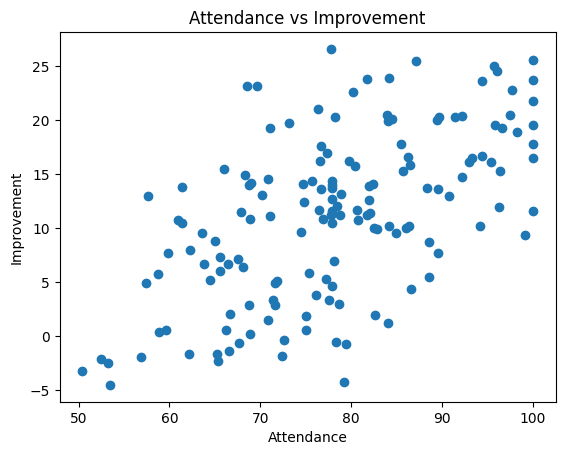

In [81]:
plt.scatter(df["Attendance"], df["Improvement"])
plt.xlabel("Attendance")
plt.ylabel("Improvement")
plt.title("Attendance vs Improvement")
plt.show()

HIGHEST PARTICIPATION PER PROGRAM

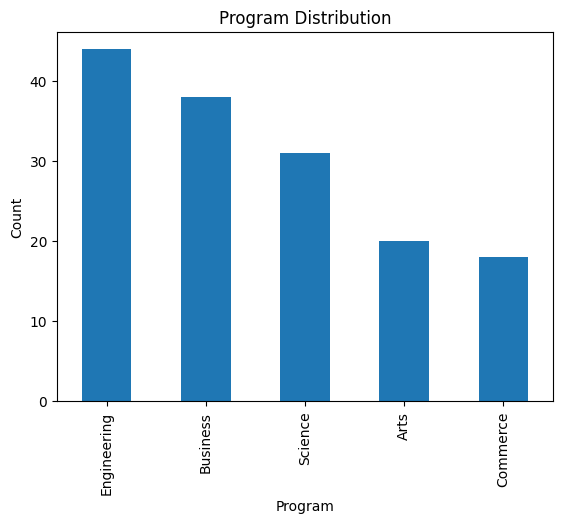

In [82]:
df["Program"].value_counts().plot(kind="bar")
plt.xlabel("Program")
plt.ylabel("Count")
plt.title("Program Distribution")
plt.show()